# Analisis Putusan Tindak Pidana Penipuan Menggunakan Case-Based Reasoning (CBR)

Notebook ini mengimplementasikan metode Case-Based Reasoning (CBR) untuk menganalisis putusan tindak pidana penipuan berdasarkan dokumen putusan pengadilan. Proses yang dilakukan meliputi pembentukan basis kasus (Case Base), representasi kasus (Case Representation), pencarian kasus serupa (Retrieve), penggunaan kembali solusi (Reuse), dan evaluasi model menggunakan Support Vector Classifier (SVC) dengan 5-Fold Cross Validation.

# STEP 1 - Case Base

Tahap ini bertujuan membangun basis kasus dengan menyiapkan struktur folder kerja yang digunakan selama proses analisis.

## Import **Library**

In [3]:
!pip -q install pdfplumber tqdm nltk

import os
import re
import pdfplumber
import pandas as pd

from pathlib import Path
from tqdm import tqdm

print("Library berhasil diimport")

Library berhasil diimport


### Konfigurasi Folder Dataset

In [8]:
from pathlib import Path

PDF_DIR = Path("/content")
RAW_DIR = Path("/content/data/raw")
PROCESSED_DIR = Path("/content/data/processed")
LOG_DIR = Path("/content/logs")

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("Folder berhasil dibuat.")

Folder berhasil dibuat.


### Fungsi Pembacaan Dokumen PDF

In [108]:
def extract_text_from_pdf(pdf_path):
    text = ""

    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()

                if page_text:
                    text += page_text + "\n"

    except Exception as e:
        print(f"Gagal membaca {pdf_path}: {e}")

    return text

### Fungsi Pembersihan Hasil OCR

In [15]:
def clean_text(text):
    cleaned_lines = []

    for line in text.splitlines():
        line = line.strip()


        if not line:
            continue


        if len(line) <= 2:
            continue

        cleaned_lines.append(line)

    text = "\n".join(cleaned_lines)


    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n+", "\n", text)

    return text.strip()

### Konversi PDF menjadi TXT

In [16]:
log_data = []

for i, pdf_file in enumerate(tqdm(pdf_files), start=1):

    pdf_path = PDF_DIR / pdf_file

    text = extract_text_from_pdf(pdf_path)

    cleaned_text = clean_text(text)

    output_path = RAW_DIR / f"case_{i:03}.txt"

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(cleaned_text)

    log_data.append({
        "Case": i,
        "File PDF": pdf_file,
        "Jumlah Karakter": len(cleaned_text),
        "Status": "Success"
    })

print("Semua PDF berhasil dikonversi.")

100%|██████████| 35/35 [03:51<00:00,  6.62s/it]

Semua PDF berhasil dikonversi.


### Pembuatan Log Ekstraksi

In [17]:
log_df = pd.DataFrame(log_data)

log_df.to_csv(LOG_DIR / "cleaning_log.csv", index=False)

log_df.head()

,Case,File PDF,Jumlah Karakter,Status
0,1,(24)putusan_1503_pid.b_2025_pn_sby_20260627045...,57143,Success
1,2,(34)putusan_2405_pid.b_2024_pn_sby_20260627062...,398212,Success
2,3,(3)putusan_576_pid.b_2025_pn_sby_2026062701294...,661290,Success
3,4,(29)putusan_1693_pid.b_2025_pn_sby_20260627050...,74865,Success
4,5,(13)putusan_2051_pid.b_2025_pn_sby_20260627032...,55481,Success


### Verifikasi File TXT

In [18]:
txt_files = list(RAW_DIR.glob("*.txt"))

print(f"Jumlah file TXT: {len(txt_files)}")

print("\nContoh isi file pertama:\n")

with open(txt_files[0], "r", encoding="utf-8") as f:
    print(f.read()[:1000])

Jumlah file TXT: 35

Contoh isi file pertama:

g e
h k
a i
m b
Direktori Putusan Mahkamah Agung Republik Indonesia
h a
putusan.mahkamahagung.go.id Pid.I.A.3
a i
P U T U S A N s
M Nomor 1389/Pid.B/2025/PN Sby
g e
DEMIn KEADILAN BERDASARKAN KETUHANAN YANG MAHA ESA n
Pengadilan Negeri Surabaya yang mengadili perkara pidana doengan
acara pemeriksaan biasa dalam tingkat pertama menjatuhkan putusan sebagai
berikut dalam perkara Terdakwa :
A1. Nama lengkap : Ade Yolando Sudirman
2. Tempat lahir : Jakarta I
h3. Umur/Tanggal lahir : 54 tahun /21 Desembekr 1970
a 4. Jenis kelamin : Laki-laki i
5. Kebangsaan : Indonesia
m b
6. Tempat tinggal : Jl. Apel No. 18 Rt. 001 Rw. 004 Kel. Petukangan
a Utara Kec. Pesanggrahan Jakarta Selatan Prov.
DKIp Jakarta atau Jl. Kereta Kencana VI Blok A 4
eNo. 50, BSD Sektor 12.1 Kel. Rawa Mekar
h a
Jaya, Kec. Serpong, Kota Tangerang Selatan,
a i
Prov. Banten atau Periang Rt. 010 Rw. 008 No. s
23 Kel. Pondok Jagung Kec. Serpong Utara,
g e
Kota Tangerang Selatan Prov

# STEP 2 - Case Representation

Tahap ini melakukan ekstraksi metadata dari setiap dokumen putusan sehingga setiap kasus memiliki representasi yang dapat diproses oleh sistem CBR.

### Import **Library** Representasi Kasus

In [109]:
import re
import pandas as pd
from pathlib import Path

### Ekstraksi Metadata dan Feature Engineering

In [110]:
def normalize_text(text):

    replacements = {
        "Septenmber": "September",
        "Nopember": "November",
        "Pebruari": "Februari",
        "Agutsus": "Agustus",
        "Januaru": "Januari",
        "Desenmber": "Desember",
        "Desenber": "Desember",
        "didalmpingi": "didampingi",
        "didamppingi": "didampingi",
        "dihaduiri": "dihadiri"
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text

# ====================================================
# 1. Nomor Perkara
# ====================================================
def extract_case_number(text):

    text = normalize_text(text)

    match = re.search(
        r'Nomor\s+(\d+/Pid\.[A-Za-z]+/\d{4}/PN\s+\w+)',
        text,
        re.IGNORECASE
    )

    if match:
        return match.group(1).strip()

    return ""


# ====================================================
# 2. Tanggal Putusan
# ====================================================
def extract_date(text):

    text = normalize_text(text)
    text = re.sub(r'\s+', ' ', text)

    match = re.search(
        r'permusyawaratan.*?tanggal\s+(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})',
        text,
        flags=re.IGNORECASE
    )

    if match:
        return match.group(1)

    return ""


# ====================================================
# 3. Nama Pengadilan
# ====================================================
def extract_court(text):

    text = normalize_text(text)

    match = re.search(
        r'Pengadilan Negeri\s+([A-Za-z]+)',
        text
    )

    if match:
        return f"Pengadilan Negeri {match.group(1)}"

    return ""


# ====================================================
# 4. Pasal
# ====================================================
def extract_article(text):

    text = normalize_text(text)

    text = re.sub(r'\s+', ' ', text)

    matches = re.findall(
        r'Pasal\s+\d+[A-Za-z]*(?:\s+ayat\s*\(\d+\))?',
        text,
        re.IGNORECASE
    )

    hasil = []

    for item in matches:

        item = item.title().strip()

        if item not in hasil:
            hasil.append(item)

    return ", ".join(hasil)


# ====================================================
# 5. Ringkasan Fakta
# ====================================================
def extract_summary(text):

    text = normalize_text(text)
    text = re.sub(r'\s+', ' ', text)

    start = 0

    keywords = [
        "Bahwa",
        "Menimbang",
        "Penuntut Umum",
        "Terdakwa"
    ]

    for key in keywords:
        idx = text.find(key)
        if idx != -1:
            start = idx
            break

    summary = text[start:start+1200]

    return summary.strip()


# ====================================================
# 6. Lama Hukuman (Label SVM)
# ====================================================
def extract_sentence(text):

    text = normalize_text(text)
    text = re.sub(r'\s+', ' ', text)

    patterns = [

        r'pidana penjara selama\s+([^.]+)\.',

        r'menjatuhkan pidana kepada terdakwa.*?selama\s+([^.]+)\.',

        r'dengan pidana penjara\s+selama\s+([^.]+)\.',

        r'selama\s+([0-9]+\s*\([^)]+\)\s*tahun(?:\s*[0-9]+\s*\([^)]+\)\s*bulan)?)'
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            text,
            re.IGNORECASE | re.DOTALL
        )

        if match:
            return match.group(1).strip()

    return ""

# ====================================================
# 7. Feature Engineering
# ====================================================
def word_count(text):

    text = normalize_text(text)

    return len(text.split())


### Uji Fungsi Ekstraksi Metadata

In [106]:
sample_file = txt_files[0]

with open(sample_file, "r", encoding="utf-8") as f:
    text = f.read()

print("Nomor Perkara :", extract_case_number(text))
print("Tanggal       :", extract_date(text))
print("Pengadilan    :", extract_court(text))
print("Pasal         :", extract_article(text))
print("Lama Hukuman  :", extract_sentence(text))
print("Jumlah Kata   :", word_count(text))

Nomor Perkara : 1389/Pid.B/2025/PN Sby
Tanggal       : 15 September 2025
Pengadilan    : Pengadilan Negeri Surabaya
Pasal         : Pasal 25, Pasal 378, Pasal 55 Ayat (1), Pasal 23, Pasal 39 Ayat (1), Pasal 46 Ayat (2), Pasal 372, Pasal 374, Pasal 3E
Lama Hukuman  : 2 (dua) tahun; e 3
Jumlah Kata   : 66254


### Membaca Seluruh Dokumen TXT

In [107]:
import re

with open(txt_files[0], "r", encoding="utf-8") as f:
    text = f.read()

tail = re.sub(r'\s+', ' ', text[-12000:])

keywords = [
    "demikian diputuskan",
    "diucapkan",
    "permusyawaratan",
    "rapat permusyawaratan",
    "sidang terbuka"
]

for key in keywords:
    idx = tail.lower().find(key)
    print(f"{key} -> {idx}")

    if idx != -1:
        print("="*80)
        print(tail[idx:idx+1200])
        print("="*80)

demikian diputuskan -> -1
diucapkan -> 10569
diucapkan dalam sidang terbuka untuk umum pada hari dan a i tanggal itu juga oleh Hakim Ketua dengan didalmpingi para Hakim Anggota m b tersebut, dibantu oleh Asep Priyatno, SH., MH, Panitera Pengganti pada Pengadilan Negeri Surabaya, serta dihaduiri oleh Yulistiono, S.H., M.H., Penuntut Umum dan Terdakwa dengan didamppingi Penasihat Hukumnya. h a Hakim Anggota, Hakim Ketua, a i g e Edi Saputra Pelawi, S.H., M.H. S. Pujiono, S.H., M.Hum Muhgammad Yusuf Karim, S.H., M.Hum. Panitera Pengganti, h k Asep Priyatno, SH., MH a i m b h a a i g e g Halaman 123 dari 123 Putusan Nomor 1389/Pid.B/2025/PN Sby h k Disclaimer Kepaniteraan Mahkamah Agunag Republik Indonesia berusaha untuk selalu mencantumkan informasi paling kini dan akurat sebagai bentuk komitmen Mahkamah Agung uintuk pelayanan publik, transparansi dan akuntabilitas pelaksanaan fungsi peradilan. Namun dalam hal-hal tertentu masih dimungkinkan terjadi permasalahan teknis terkait dengan akur

### Membangun Dataset Kasus

In [112]:
cases = []

for i, txt_file in enumerate(tqdm(txt_files), start=1):

    with open(txt_file, "r", encoding="utf-8") as f:
        text = f.read()

    case = {
        "case_id": i,
        "file_name": txt_file.name,
        "nomor_perkara": extract_case_number(text),
        "tanggal_putusan": extract_date(text),
        "pengadilan": extract_court(text),
        "jenis_perkara": "Penipuan",
        "pasal": extract_article(text),
        "ringkasan_fakta": extract_summary(text),
        "lama_hukuman": extract_sentence(text),
        "word_count": word_count(text),
        "text_full": text
    }

    cases.append(case)

cases_df = pd.DataFrame(cases)

print("Jumlah Case :", len(cases_df))
cases_df.head()

100%|██████████| 35/35 [00:02<00:00, 17.18it/s]


Jumlah Case : 35


,case_id,file_name,nomor_perkara,tanggal_putusan,pengadilan,jenis_perkara,pasal,ringkasan_fakta,lama_hukuman,word_count,text_full
0,1,case_026.txt,1389/Pid.B/2025/PN Sby,15 September 2025,Pengadilan Negeri Surabaya,Penipuan,"Pasal 25, Pasal 378, Pasal 55 Ayat (1), Pasal ...",Bahwa ia Terdakwa ADE YOLANDO beirsama dengan ...,2 (dua) tahun; e 3,66254,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
1,2,case_015.txt,1769/Pid.B/2025/PN Sby,,Pengadilan Negeri Surabaya,Penipuan,Pasal 378,Bahwa terdakwa HERI WIBOWO Bin SUHARIYANI pada...,3 (Tiga) tahun penjara,11551,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
2,3,case_023.txt,392/Pid.B/2025/PN Sby,,Pengadilan Negeri Surabaya,Penipuan,"Pasal 378, Pasal 64 Ayat (1), Pasal 372, Pasal 64",Bahwa ia Terdakwa DIAN NUGROHO Bin PRAWOTO (AL...,1 (satu) tahun dan 6 (enam) bulan; a i 3,10320,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
3,4,case_009.txt,344/Pid.B/2025/PN Sby,10 April 2025,Pengadilan Negeri Surabaya,Penipuan,"Pasal 25, Pasal 378, Pasal 372",Bahwa ia Terdakwa Miftahul Jannah Bin Abdul Ba...,2 (Dua) tahun dikurangi selama Terdakwa i dita...,11782,g e\nh k\na i\nm b\nDirek tori Putusan Mahkama...
4,5,case_001.txt,1503/Pid.B/2025/PN Sby,,Pengadilan Negeri Surabaya,Penipuan,Pasal 378,Bahwa saya adalah orang tua tunggal dari dua a...,1(satu) Tahun dan 6(enam) Bulan,9676,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...


### Menyimpan Dataset ke CSV

In [61]:
output_path = PROCESSED_DIR / "cases.csv"

cases_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset berhasil disimpan")
print(output_path)

Dataset berhasil disimpan
/content/data/processed/cases.csv


### Verifikasi Dataset

In [62]:
print("=" * 60)

print("Informasi Dataset")
print(cases_df.info())

print("=" * 60)

display(cases_df.head())

print("=" * 60)

display(cases_df.sample(3))

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   case_id          35 non-null     int64 
 1   file_name        35 non-null     object
 2   nomor_perkara    35 non-null     object
 3   tanggal_putusan  35 non-null     object
 4   pengadilan       35 non-null     object
 5   jenis_perkara    35 non-null     object
 6   pasal            35 non-null     object
 7   ringkasan_fakta  35 non-null     object
 8   lama_hukuman     35 non-null     object
 9   word_count       35 non-null     int64 
 10  text_full        35 non-null     object
dtypes: int64(2), object(9)
memory usage: 3.1+ KB
None


,case_id,file_name,nomor_perkara,tanggal_putusan,pengadilan,jenis_perkara,pasal,ringkasan_fakta,lama_hukuman,word_count,text_full
0,1,case_026.txt,1389/Pid.B/2025/PN Sby,15 September 2025,Pengadilan Negeri Surabaya,Penipuan,"Pasal 25, Pasal 378, Pasal 55 Ayat (1), Pasal ...",g e h k a i m b Direktori Putusan Mahkamah Agu...,2 (dua) tahun; e 3,66254,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
1,2,case_015.txt,1769/Pid.B/2025/PN Sby,,Pengadilan Negeri Surabaya,Penipuan,Pasal 378,g e h k a i m b Direktori Putusan Mahkamah Agu...,3 (Tiga) tahun penjara,11551,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
2,3,case_023.txt,392/Pid.B/2025/PN Sby,,Pengadilan Negeri Surabaya,Penipuan,"Pasal 378, Pasal 64 Ayat (1), Pasal 372, Pasal 64",g e h k a i m b Direktori Putusan Mahkamah Agu...,1 (satu) tahun dan 6 (enam) bulan; a i 3,10320,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
3,4,case_009.txt,344/Pid.B/2025/PN Sby,10 April 2025,Pengadilan Negeri Surabaya,Penipuan,"Pasal 25, Pasal 378, Pasal 372",g e h k a i m b Direk tori Putusan Mahkamah Ag...,2 (Dua) tahun dikurangi selama Terdakwa i dita...,11782,g e\nh k\na i\nm b\nDirek tori Putusan Mahkama...
4,5,case_001.txt,1503/Pid.B/2025/PN Sby,,Pengadilan Negeri Surabaya,Penipuan,Pasal 378,g e h k a i m b Direktori Putusan Mahkamah Agu...,1(satu) Tahun dan 6(enam) Bulan,9676,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...


,case_id,file_name,nomor_perkara,tanggal_putusan,pengadilan,jenis_perkara,pasal,ringkasan_fakta,lama_hukuman,word_count,text_full
13,14,case_033.txt,1133/Pid.B/2025/PN Sby,25 Juni 2025,Pengadilan Negeri Surabaya,Penipuan,"Pasal 378, Pasal 372, Pasal 44, Pasal 39 Ayat (1)",g e h k a i m b Direktori Putusan Mahkamah Agu...,1(satu) tahun dan 3(tiga) bulan; h k 3,13533,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
32,33,case_035.txt,648/Pid.B/2025/PN Sby,20 Mei 2025,Pengadilan Negeri Surabaya,Penipuan,"Pasal 378, Pasal 55 Ayat (1), Pasal 372",g e h k a i m b Direktori Putusan Mahkamah Agu...,2 (dua) tahun dan 5 (lima) bulan; a i 3,18100,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
5,6,case_022.txt,1378/Pid.B/2025/PN Sby,,Pengadilan Negeri Surabaya,Penipuan,"Pasal 25, Pasal 378, Pasal 362, Pasal 39 Ayat ...",g e h k a i m b Direktori Putusan Mahkamah Agu...,3 (tigba) tahun dan 10 (sepuluh) bulan dikuran...,17732,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...


# STEP 3 - Retrieve

Tahap Retrieve menggunakan TF-IDF sebagai representasi dokumen dan Cosine Similarity untuk mencari kasus yang memiliki tingkat kemiripan tertinggi terhadap query.

### Memuat Dataset

In [113]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.svm import SVC

### Persiapan Data Retrieval

In [63]:
cases_df = pd.read_csv(PROCESSED_DIR / "cases.csv")

print("Jumlah kasus :", len(cases_df))

cases_df.head()

Jumlah kasus : 35


,case_id,file_name,nomor_perkara,tanggal_putusan,pengadilan,jenis_perkara,pasal,ringkasan_fakta,lama_hukuman,word_count,text_full
0,1,case_026.txt,1389/Pid.B/2025/PN Sby,15 September 2025,Pengadilan Negeri Surabaya,Penipuan,"Pasal 25, Pasal 378, Pasal 55 Ayat (1), Pasal ...",g e h k a i m b Direktori Putusan Mahkamah Agu...,2 (dua) tahun; e 3,66254,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
1,2,case_015.txt,1769/Pid.B/2025/PN Sby,NaN,Pengadilan Negeri Surabaya,Penipuan,Pasal 378,g e h k a i m b Direktori Putusan Mahkamah Agu...,3 (Tiga) tahun penjara,11551,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
2,3,case_023.txt,392/Pid.B/2025/PN Sby,NaN,Pengadilan Negeri Surabaya,Penipuan,"Pasal 378, Pasal 64 Ayat (1), Pasal 372, Pasal 64",g e h k a i m b Direktori Putusan Mahkamah Agu...,1 (satu) tahun dan 6 (enam) bulan; a i 3,10320,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...
3,4,case_009.txt,344/Pid.B/2025/PN Sby,10 April 2025,Pengadilan Negeri Surabaya,Penipuan,"Pasal 25, Pasal 378, Pasal 372",g e h k a i m b Direk tori Putusan Mahkamah Ag...,2 (Dua) tahun dikurangi selama Terdakwa i dita...,11782,g e\nh k\na i\nm b\nDirek tori Putusan Mahkama...
4,5,case_001.txt,1503/Pid.B/2025/PN Sby,NaN,Pengadilan Negeri Surabaya,Penipuan,Pasal 378,g e h k a i m b Direktori Putusan Mahkamah Agu...,1(satu) Tahun dan 6(enam) Bulan,9676,g e\nh k\na i\nm b\nDirektori Putusan Mahkamah...


### Pembentukan TF-IDF

In [64]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    max_features=5000
)

tfidf_matrix = vectorizer.fit_transform(
    cases_df["text_full"]
)

print("Shape TF-IDF :", tfidf_matrix.shape)

Shape TF-IDF : (35, 5000)


### Bag of Words

Bag of Words digunakan untuk merepresentasikan frekuensi kemunculan kata pada setiap dokumen. Representasi ini digunakan sebagai pembanding terhadap TF-IDF yang memberikan bobot berdasarkan tingkat kepentingan kata pada seluruh dokumen.

In [103]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(
    max_features=5000
)

bow_matrix = bow.fit_transform(
    cases_df["text_full"]
)

print("Bag of Words Shape :", bow_matrix.shape)

Bag of Words Shape : (35, 5000)


### Perhitungan Cosine Similarity

In [65]:
similarity_matrix = cosine_similarity(tfidf_matrix)

print(similarity_matrix.shape)

(35, 35)


### Fungsi Retrieval Kasus

In [66]:
def retrieve(query, top_k=5):

    query_vector = vectorizer.transform([query])

    similarity_scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    )[0]

    top_indices = np.argsort(similarity_scores)[::-1][:top_k]

    result = cases_df.iloc[top_indices].copy()

    result["similarity"] = similarity_scores[top_indices]

    return result[
        [
            "case_id",
            "nomor_perkara",
            "lama_hukuman",
            "similarity"
        ]
    ]

### Pengujian Retrieval

In [67]:
query = """
Terdakwa melakukan penipuan investasi dengan kerugian miliaran rupiah
"""

retrieve(query)

,case_id,nomor_perkara,lama_hukuman,similarity
3,4,344/Pid.B/2025/PN Sby,2 (Dua) tahun dikurangi selama Terdakwa i dita...,0.233139
12,13,1431/Pid.B/2024/PN Sby,4 (empat) tahun,0.153420
17,18,1506/Pid.B/2025/PN Sby,1 (satu) tahun,0.131406
5,6,1378/Pid.B/2025/PN Sby,3 (tigba) tahun dan 10 (sepuluh) bulan dikuran...,0.124587
21,22,1402/Pid.B/2025/PN Sby,": 1 (satu) Tahun dan 2 i (dua) Bulan ,dikura n...",0.119508


# STEP 4 - Reuse

Tahap Reuse menggunakan algoritma Support Vector Classifier (SVC) untuk mengklasifikasikan kategori hukuman berdasarkan representasi dokumen yang telah dibentuk.

### Konversi Lama Hukuman

In [120]:
import re
import pandas as pd

def convert_to_months(text):

    if pd.isna(text):
        return None

    text = str(text).lower()

    tahun = 0
    bulan = 0

    t = re.search(r'(\d+)\s*\([^)]+\)\s*tahun|(\d+)\s*tahun', text)
    if t:
        tahun = int(t.group(1) or t.group(2))

    b = re.search(r'(\d+)\s*\([^)]+\)\s*bulan|(\d+)\s*bulan', text)
    if b:
        bulan = int(b.group(1) or b.group(2))

    return tahun * 12 + bulan


cases_df["bulan"] = cases_df["lama_hukuman"].apply(convert_to_months)

### Pembuatan Label Kelas

In [121]:
def create_label(month):

    if pd.isna(month):
        return None

    if month <= 24:
        return "Ringan"

    elif month <= 48:
        return "Sedang"

    else:
        return "Berat"


cases_df["label"] = cases_df["bulan"].apply(create_label)

display(cases_df[["lama_hukuman","bulan","label"]].head())

,lama_hukuman,bulan,label
0,2 (dua) tahun; e 3,24,Ringan
1,3 (Tiga) tahun penjara,36,Sedang
2,1 (satu) tahun dan 6 (enam) bulan; a i 3,18,Ringan
3,2 (Dua) tahun dikurangi selama Terdakwa i dita...,24,Ringan
4,1(satu) Tahun dan 6(enam) Bulan,18,Ringan


### Pelatihan Model SVC dengan 5-Fold Cross Validation

In [122]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict

X = tfidf_matrix
y = cases_df["label"]

model = SVC(
    kernel="linear",
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

prediction = cross_val_predict(
    model,
    X,
    y,
    cv=cv
)

print("Cross Validation selesai")

Cross Validation selesai


In [123]:
model.fit(X, y)

print("Model akhir berhasil dilatih.")

Model akhir berhasil dilatih.


### Hasil Prediksi Model

In [116]:
hasil = pd.DataFrame({
    "Aktual": y,
    "Prediksi": prediction
})

display(hasil.head(10))

,Aktual,Prediksi
0,Ringan,Sedang
1,Sedang,Ringan
2,Ringan,Ringan
3,Ringan,Ringan
4,Ringan,Ringan
5,Sedang,Ringan
6,Sedang,Ringan
7,Ringan,Ringan
8,Sedang,Ringan
9,Ringan,Ringan


# STEP 5 - Evaluation

Tahap evaluasi dilakukan menggunakan 5-Fold Cross Validation dengan metrik Accuracy, Precision, Recall, dan F1-Score untuk mengukur performa model klasifikasi.

### Perhitungan Metrik Evaluasi

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y, prediction)

precision = precision_score(
    y,
    prediction,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y,
    prediction,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y,
    prediction,
    average="weighted",
    zero_division=0
)

print("="*40)
print("HASIL EVALUASI MODEL")
print("="*40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

HASIL EVALUASI MODEL
Accuracy : 0.6000
Precision: 0.5636
Recall   : 0.6000
F1 Score : 0.4944


### Confusion Matrix dan Classification Report

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar maupun salah pada masing-masing kelas sehingga performa model dapat dianalisis lebih rinci.

In [96]:
from sklearn.metrics import confusion_matrix, classification_report

labels = sorted(y.unique())

cm = confusion_matrix(
    y,
    prediction,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print("Confusion Matrix")
display(cm_df)

print("\nClassification Report\n")

print(
    classification_report(
        y,
        prediction,
        labels=labels,
        zero_division=0
    )
)

Confusion Matrix


,Ringan,Sedang
Ringan,20,1
Sedang,13,1



Classification Report

              precision    recall  f1-score   support

      Ringan       0.61      0.95      0.74        21
      Sedang       0.50      0.07      0.12        14

    accuracy                           0.60        35
   macro avg       0.55      0.51      0.43        35
weighted avg       0.56      0.60      0.49        35



### Visualisasi Confusion Matrix

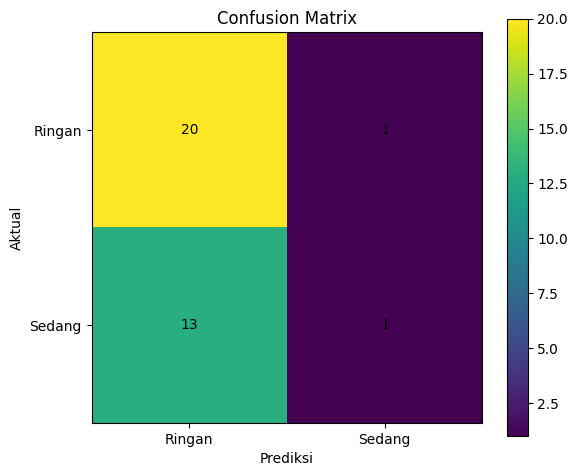

In [97]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,5))

plt.imshow(cm, interpolation='nearest')

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(labels))

plt.xticks(tick_marks, labels)

plt.yticks(tick_marks, labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.tight_layout()

plt.show()

### Error Analysis

In [124]:
print("Data yang salah diprediksi")

error_df = hasil[
    hasil["Aktual"] != hasil["Prediksi"]
]

display(error_df)

Data yang salah diprediksi


,Aktual,Prediksi
0,Ringan,Sedang
1,Sedang,Ringan
5,Sedang,Ringan
6,Sedang,Ringan
8,Sedang,Ringan
12,Sedang,Ringan
15,Sedang,Ringan
18,Sedang,Ringan
22,Sedang,Ringan
26,Sedang,Ringan


### Menyimpan Hasil Evaluasi

In [98]:
hasil.to_csv(
    PROCESSED_DIR / "predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

metrics = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics.to_csv(
    PROCESSED_DIR / "evaluation_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

print("predictions.csv berhasil disimpan")

print("evaluation_metrics.csv berhasil disimpan")

predictions.csv berhasil disimpan
evaluation_metrics.csv berhasil disimpan


### Ringkasan Hasil Evaluasi

In [99]:
print("="*60)
print("RINGKASAN HASIL")
print("="*60)

print(f"Jumlah Kasus          : {len(cases_df)}")
print(f"Jumlah Feature TF-IDF : {tfidf_matrix.shape[1]}")
print(f"Jumlah Kelas          : {len(labels)}")

print()

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

RINGKASAN HASIL
Jumlah Kasus          : 35
Jumlah Feature TF-IDF : 5000
Jumlah Kelas          : 2

Accuracy  : 0.6000
Precision : 0.5636
Recall    : 0.6000
F1 Score  : 0.4944


## Analisis Hasil Evaluasi

Berdasarkan hasil evaluasi menggunakan 5-Fold Cross Validation, model memperoleh Accuracy sebesar 60,00%, Precision sebesar 56,36%, Recall sebesar 60,00%, dan F1-Score sebesar 49,44%.

Nilai tersebut menunjukkan bahwa model telah mampu melakukan klasifikasi kategori hukuman, namun performanya masih dapat ditingkatkan. Hal ini dipengaruhi oleh jumlah dataset yang relatif sedikit, distribusi kelas yang belum seimbang, serta variasi isi dokumen putusan yang cukup beragam. Penggunaan dataset yang lebih besar dan teknik preprocessing yang lebih baik berpotensi meningkatkan performa model.